<a href="https://colab.research.google.com/github/Lmarra1/sympy-workshop-UC3M-2025/blob/main/pendulum_approximations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
# Import packages
import sympy as sp
from IPython.display import display

In [58]:
# Symbols for pendulum
g     = sp.Symbol('g', positive=True)
L     = sp.Symbol('L', positive=True)
omega = sp.Symbol('omega')
theta = sp.Symbol('theta')

# Nonlinear pendulum equation: θ'' = -(g/L) * sin(θ)
f     = - (g/L) * sp.sin(theta)

print('\nThe pendulum equation:\n')
display(f)



The pendulum equation:



-g*sin(theta)/L

We can do a Taylor series approximations of $\mathrm{sin}(\theta)$ around $\theta = 0$:

$$ \mathrm{sin}(\theta) = \sum_{n = 0}^{\infty} \frac{(-1)}{(2n+1)!} x^{2n+1}$$

there are only odd terms.


**Let's do it with sympy...**

In [59]:
# Expansion of the equation at the order n = 1,2,3...

# First order approximation
f_1_o = f.series(theta, 0, 2)
print("\nFirst order approximation:\n")
display(f_1_o)

# First order approximation
f_1 = f.series(theta, 0, 2).removeO()
print("\nRemoving the O term:\n")
display(f_1)

# Second order approximation
f_2 = f.series(theta, 0, 3).removeO()
print("\nSecond order approximation:\n")
display(f_2)

# Third order approximation
f_3 = f.series(theta, 0, 4).removeO()
print("\nThird order approximation:\n")
display(f_3)

# Fourth order approximation
f_4 = f.series(theta, 0, 5).removeO()
print("\nFourth order approximation:\n")
display(f_4)

# Fifth order approximation
f_5 = f.series(theta, 0, 6).removeO()
print("\nFifth order approximation:\n")
display(f_5)



First order approximation:



-g*theta/L + O(theta**2)


Removing the O term:



-g*theta/L


Second order approximation:



...

g*theta**3/(6*L) - g*theta/L


Fourth order approximation:



g*theta**3/(6*L) - g*theta/L


Fifth order approximation:



-g*theta**5/(120*L) + g*theta**3/(6*L) - g*theta/L

Comparison of the integration results for different orders of approximation of the dynamics
- full order dynamics
- first order approximation
- n-th order approximation

In [63]:
# Importing numpy and solve_ivp from scipy packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# n-th order approximation
n   = 4
f_n = f.series(theta, 0, n+1).removeO()
print(f"\n General n-th order approximation (n = {n} selected):\n")
display(f_n)


# Dynamics (state vector: x = [theta, omega])
F_full = sp.Matrix([omega, f])
F_1    = sp.Matrix([omega, f_1])
F_n    = sp.Matrix([omega, f_n])

print("\n Full dynamics: \n")
display(F_full)

print("\n First-order approximation of the dynamics: \n")
display(F_1)

print("\n nth-order approximation of the dynamics: \n")
display(F_n)


# Parameters
g_val = 9.81
L_val = 1.0


# Initial conditions for theta and omega
theta_0 = np.pi / 2
omega_0 = 0.0
x0      = [theta_0, omega_0]

# Time span
t_span = (0, 30)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Lambdify: convert symbolic to numerical functions for integration
F_full_func  = sp.lambdify([theta, omega, g, L]   , F_full, 'numpy')
F_1_func     = sp.lambdify([theta, omega, g, L]   , F_1,    'numpy')
F_n_func     = sp.lambdify([theta, omega, g, L]   , F_n,    'numpy')

# ODE wrappers
def dyn_full(t, x):  return F_full_func(x[0], x[1], g_val, L_val).flatten()
def dyn_1(t, x):     return F_1_func(x[0], x[1], g_val, L_val).flatten()
def dyn_n(t, x):     return F_n_func(x[0], x[1], g_val, L_val).flatten()

# Solve ODEs
sol_full  = solve_ivp(dyn_full, t_span, x0, t_eval=t_eval)
sol_1     = solve_ivp(dyn_1, t_span, x0, t_eval=t_eval)
sol_n     = solve_ivp(dyn_n, t_span, x0, t_eval=t_eval)



 General n-th order approximation (n = 4 selected):



g*theta**3/(6*L) - g*theta/L


 Full dynamics: 



Matrix([
[          omega],
[-g*sin(theta)/L]])


 First-order approximation of the dynamics: 



Matrix([
[     omega],
[-g*theta/L]])


 nth-order approximation of the dynamics: 



Matrix([
[                       omega],
[g*theta**3/(6*L) - g*theta/L]])

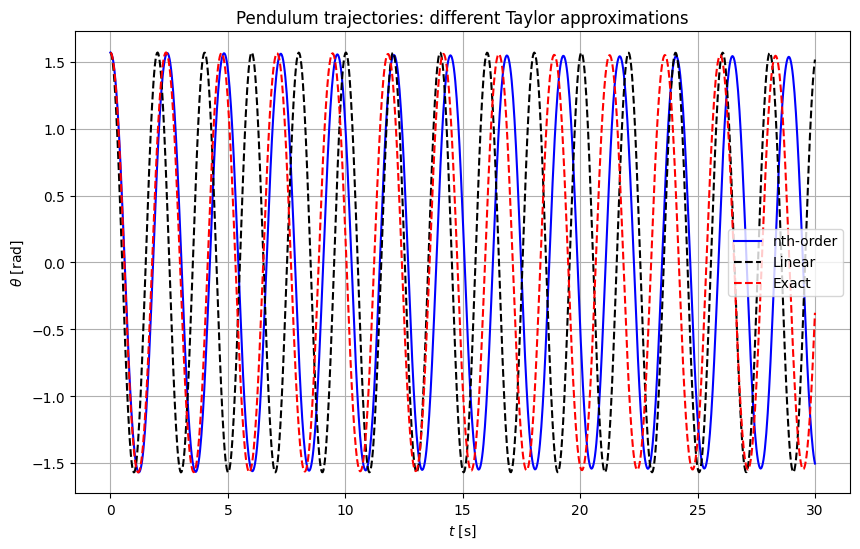

In [62]:

# Plot results
plt.figure(figsize=(10,6))
plt.plot(sol_n.t, sol_n.y[0],'b-', label='nth-order')
plt.plot(sol_1.t, sol_1.y[0],'k--', label='Linear')
plt.plot(sol_full.t, sol_full.y[0], 'r--', label='Exact')
plt.xlabel('$t$ [s]')
plt.ylabel(r'$\theta$ [rad]')
plt.title('Pendulum trajectories: different Taylor approximations')
plt.legend()
plt.grid(True)
plt.show()